# you only look once

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import display, Image
import torch
import random

In [8]:
# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [9]:
# Initialize detection model
model_det = YOLO("yolov8n.pt") 

In [4]:
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://ultralytics.com/images/bus.jpg' save=True

Ultralytics 8.3.4 🚀 Python-3.12.4 torch-2.4.1 CPU (Apple M3 Max)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

100%|█████████████████████████████████████████| 134k/134k [00:00<00:00, 154MB/s]
image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 26.0ms
Speed: 1.6ms preprocess, 26.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /Users/n0man/Code/n03an.me/runs/detect/predict6
💡 Learn more at https://docs.ultralytics.com/modes/predict



image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 35.8ms
Speed: 2.7ms preprocess, 35.8ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 480)


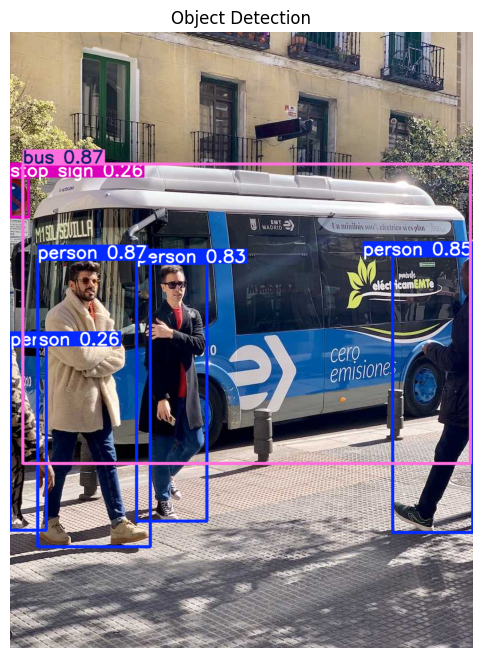

In [15]:
# Run detection
det_results = model_det("images/bus.jpg")

# Visualize results
plt.figure(figsize=(12, 8))
plt.imshow(det_results[0].plot()[:, :, ::-1])  # Convert BGR to RGB
plt.title("Object Detection")
plt.axis('off')
plt.show()


image 1/1 /Users/n0man/Code/n03an.me/notebooks/va/images/dog.jpeg: 640x384 1 person, 1 car, 1 dog, 25.9ms
Speed: 1.7ms preprocess, 25.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 384)


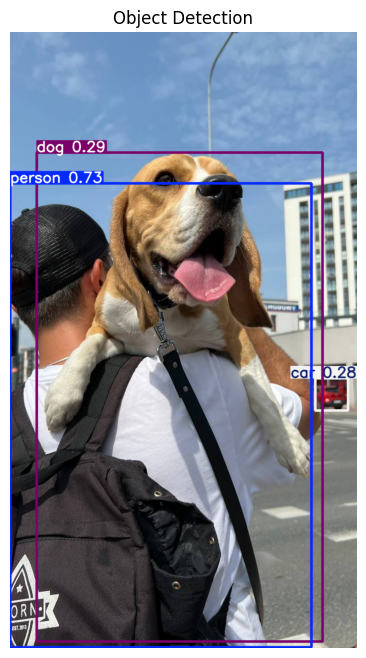

In [23]:
# Run detection
det_results = model_det("images/dog.jpeg")

# Visualize results
plt.figure(figsize=(12, 8))
plt.imshow(det_results[0].plot()[:, :, ::-1])  # Convert BGR to RGB
plt.title("Object Detection")
plt.axis('off')
plt.show()

In [12]:
# Initialize pose estimation model (required for action recognition)
model_pose = YOLO("yolov8n-pose.pt")  # Pose estimation model

100%|██████████| 6.52M/6.52M [00:00<00:00, 7.85MB/s]


In [16]:
def get_angle(a, b, c):
    """Calculate the angle between three keypoints (b is the vertex)."""
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.norm(bc) + 1e-10)
    angle = np.arccos(np.clip(cosine_angle, -1.0, 1.0))
    return np.degrees(angle)

In [17]:
def is_sitting(keypoints):
    """Determine if a person is sitting based on leg angles and positions."""
    left_hip = keypoints[11][:2]
    left_knee = keypoints[13][:2]
    left_ankle = keypoints[15][:2]
    right_hip = keypoints[12][:2]
    right_knee = keypoints[14][:2]
    right_ankle = keypoints[16][:2]

    # Check knee bend angles (sitting: angles < 140°)
    left_angle = get_angle(left_hip, left_knee, left_ankle) if all(left_ankle) else 180
    right_angle = get_angle(right_hip, right_knee, right_ankle) if all(right_ankle) else 180
    
    return left_angle < 140 or right_angle < 140

In [18]:
def is_running(keypoints):
    """Determine if a person is running based on leg positions."""
    left_ankle = keypoints[15][:2]
    right_ankle = keypoints[16][:2]
    nose = keypoints[0][:2]
    mid_hip = ((keypoints[11][0] + keypoints[12][0]) / 2, 
               (keypoints[11][1] + keypoints[12][1]) / 2)

    if not all(left_ankle) or not all(right_ankle) or not all(nose) or not all(mid_hip):
        return False

    # Calculate vertical spread between ankles
    ankle_spread = abs(left_ankle[1] - right_ankle[1])
    body_height = abs(nose[1] - mid_hip[1])
    
    return ankle_spread > 0.3 * body_height  # Significant leg spread indicates running

In [20]:
model = YOLO("yolov8n-pose.pt")

In [21]:
def detect_behaviors(image_path):
    # Load image
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = model(image_rgb, conf=0.5)  # Run inference
    
    # Prepare visualization
    output_image = image_rgb.copy()
    behaviors = []
    
    for result in results:
        if result.keypoints is None:
            continue
            
        for i, keypoints in enumerate(result.keypoints.xy.cpu().numpy()):
            # Check keypoint confidence (skip if < 0.5)
            kp_conf = result.keypoints.conf.cpu().numpy()[i]
            valid_kp = keypoints[kp_conf > 0.5]
            if len(valid_kp) < 5:  # Skip if too few keypoints
                continue
                
            # Detect behaviors
            sitting = is_sitting(keypoints)
            running = is_running(keypoints)
            
            # Label the person
            label = []
            if sitting:
                label.append("Sitting")
            elif running:
                label.append("Running")
            else:
                label.append("Standing/Walking")
                
            # Draw bounding box and label
            bbox = result.boxes.xyxy[i].cpu().numpy()
            cv2.rectangle(output_image, 
                          (int(bbox[0]), int(bbox[1])), 
                          (int(bbox[2]), int(bbox[3])), 
                          (0, 255, 0), 2)
            cv2.putText(output_image, ", ".join(label), 
                        (int(bbox[0]), int(bbox[1]) - 10), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)
    
    return output_image

# Example usage
result_image = detect_behaviors("images/ko.jpg")
plt.figure(figsize=(10, 10))
plt.imshow(result_image)
plt.axis('off')
plt.show()


0: 384x640 7 persons, 26.5ms
Speed: 1.4ms preprocess, 26.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


AttributeError: module 'numpy' has no attribute 'norm'